# Adverse Selection Detection — 2024 Election Markets

**Applying Dalen (2025) RN-JD calibration to Kalshi presidential & senate markets**

Reference: *Toward Black-Scholes for Prediction Markets* (arXiv:2510.15205)

---

### Why Election Markets?
Election night is **news-driven**: results arrive in batches, exit polls leak, and
prices jump on new information. This creates ideal conditions for adverse selection —
informed traders may react to early precinct data before public updates. We test
the AS detector on 2024 state-level markets (PA, NV, VA, AZ, WI, IL, CO).

### Structure
1. Data loading
2. RN-JD calibration
3. AS detection showcase (most liquid: PA)
4. Fill toxicity validation
5. Market-making backtest (Naive vs AS-informed)
6. Threshold sweep
7. Cross-state co-jump analysis
8. Summary


In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats as sp_stats

from src.as_detector import run_as_detection, run_all_tickers, ASResult
from src.mm_backtest import (
    compare_strategies, compare_all_tickers,
    sweep_thresholds, backtest_mm, analyse_fill_toxicity,
)

plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

import glob
CACHE = os.path.join('..', 'cache', 'kalshi_hf_election')
all_files = sorted(glob.glob(os.path.join(CACHE, '*_trades.parquet')))
print(f"Found {len(all_files)} parquet files")

data = {}
for f in all_files:
    tkr = os.path.basename(f).replace("_trades.parquet", "")
    df = pd.read_parquet(f).sort_values("timestamp").reset_index(drop=True)
    if len(df) >= 250:
        data[tkr] = df

data = dict(sorted(data.items(), key=lambda x: -len(x[1])))
print(f"Loaded {len(data)} tickers with >= 250 trades")
print(f"Total trades: {sum(len(v) for v in data.values()):,}")
for tkr, df in list(data.items())[:20]:
    print(f"  {tkr:<30s}  {len(df):>6,} trades  [{df['mid_price'].min():.2f} - {df['mid_price'].max():.2f}]")

Found 20 parquet files
Loaded 17 tickers with >= 250 trades
Total trades: 113,499
  PRESPARTYPA-24-R                25,552 trades  [0.01 - 0.99]
  PRESPARTYPA-24-D                18,620 trades  [0.01 - 0.55]
  PRESPARTYNV-24-R                14,929 trades  [0.43 - 0.99]
  PRESPARTYNV-24-D                11,599 trades  [0.01 - 0.57]
  PRESPARTYVA-24-R                11,050 trades  [0.01 - 0.39]
  PRESPARTYAZ-24-D                 8,452 trades  [0.01 - 0.36]
  PRESPARTYAZ-24-R                 8,315 trades  [0.06 - 0.99]
  PRESPARTYVA-24-D                 5,665 trades  [0.70 - 0.99]
  SENATEWI-24-R                    2,727 trades  [0.01 - 0.89]
  SENATEWI-24-D                    1,752 trades  [0.01 - 0.99]
  PRESPARTYIL-24-R                 1,369 trades  [0.01 - 0.11]
  PRESPARTYCO-24-R                 1,063 trades  [0.01 - 0.31]
  PRESPARTYCO-24-D                   746 trades  [0.62 - 0.99]
  PRESPARTYIL-24-D                   715 trades  [0.90 - 0.99]
  PRESPARTYIN-24-D                  

## 2. RN-JD Calibration

In [10]:
all_as = run_all_tickers(data, em_window=200, em_iterations=8)
print(f"Calibrated {len(all_as)} tickers")

cal_rows = [ar.calibration_summary for tkr, ar in sorted(all_as.items(), key=lambda x: -len(x[1].prices))]
cal_df = pd.DataFrame(cal_rows)
cols = ["ticker", "n_trades", "mean_sigma_b", "mean_lambda", "n_jumps_detected", "n_bursts_detected", "pct_flagged"]
print(cal_df[cols].to_string(index=False, float_format="%.5f"))

[2026-03-03 03:49:42 UTC] [INFO] tauroi.as_detector — AS detection PRESPARTYPA-24-R: 25552 trades, 4368 jumps (γ>0.5), 3306 bursts, 4206 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.01725
[2026-03-03 03:49:47 UTC] [INFO] tauroi.as_detector — AS detection PRESPARTYPA-24-D: 18620 trades, 3638 jumps (γ>0.5), 2708 bursts, 3456 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.02730
[2026-03-03 03:49:51 UTC] [INFO] tauroi.as_detector — AS detection PRESPARTYNV-24-R: 14929 trades, 3084 jumps (γ>0.5), 1857 bursts, 2959 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.01437
[2026-03-03 03:49:55 UTC] [INFO] tauroi.as_detector — AS detection PRESPARTYNV-24-D: 11599 trades, 2545 jumps (γ>0.5), 1515 bursts, 2456 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.01648
[2026-03-03 03:49:58 UTC] [INFO] tauroi.as_detector — AS detection PRESPARTYVA-24-R: 11050 trades, 2540 jumps (γ>0.5), 1880 bursts, 2446 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.03090
[2026-03-03 03:50:01 UTC] [INFO] tauroi.as_detecto

## 3. AS Detection Showcase (PA Republican — Most Liquid)

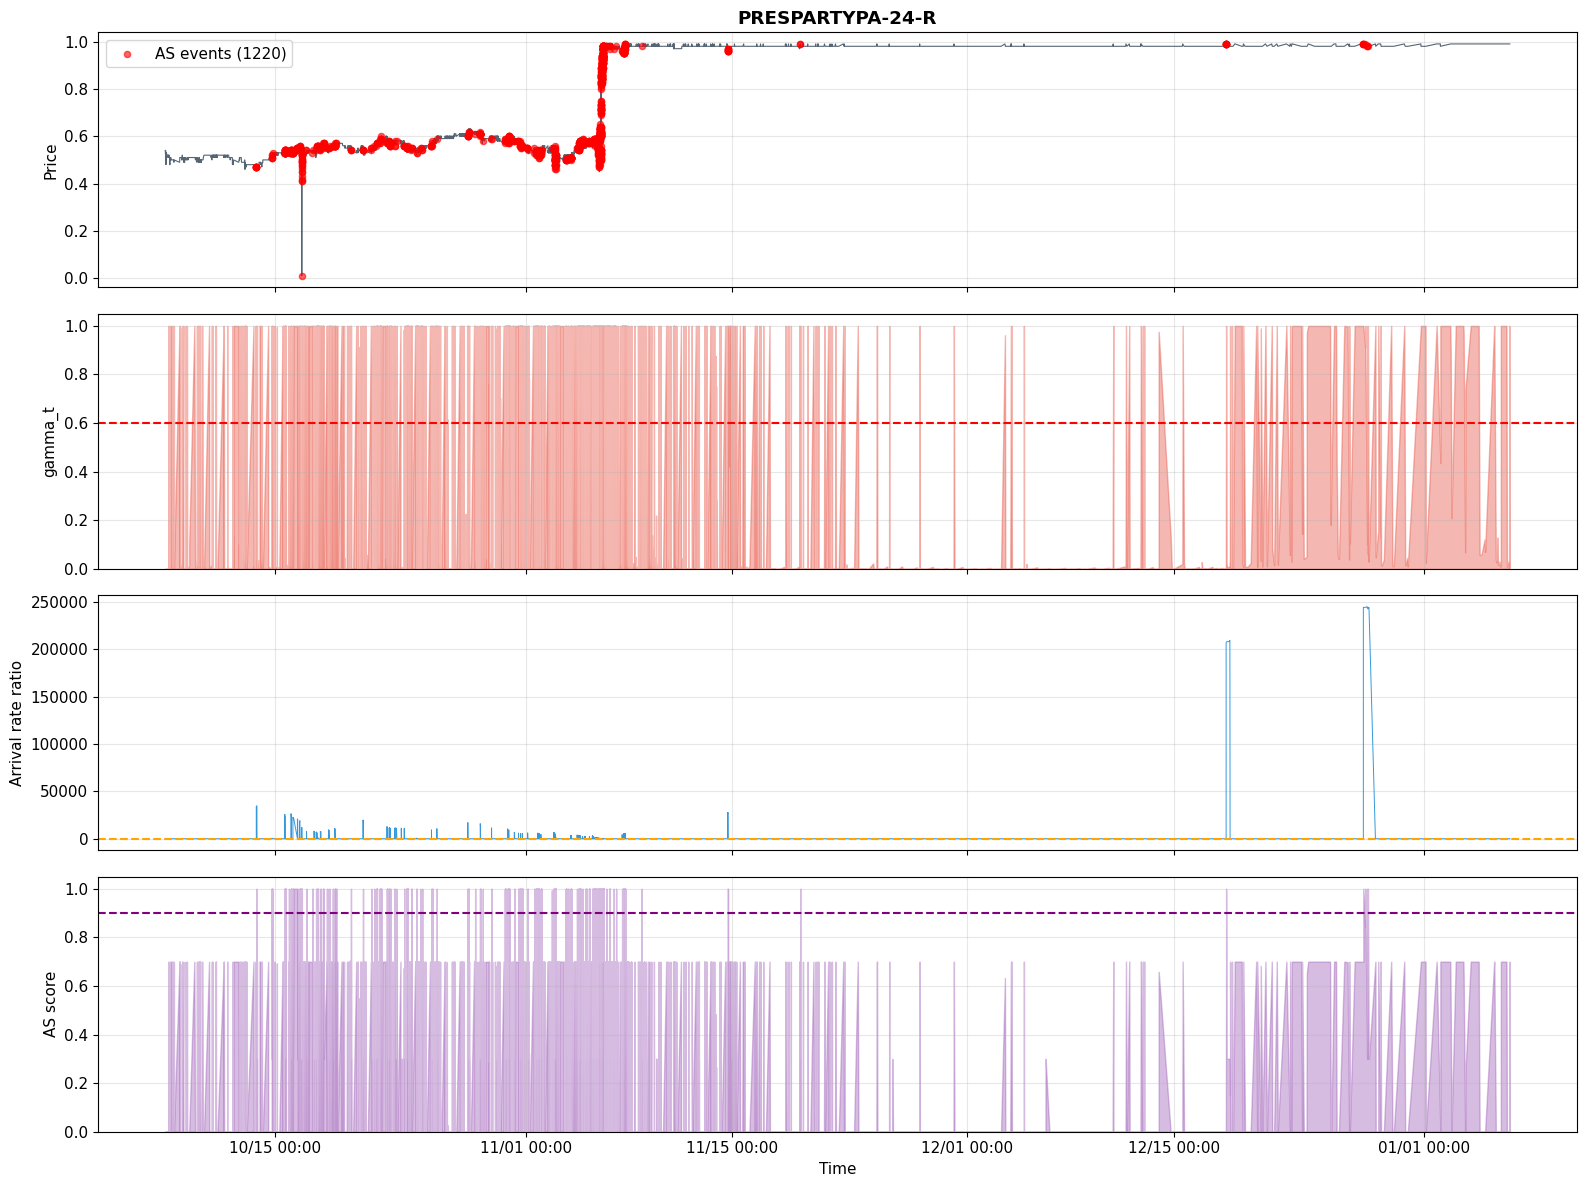

In [11]:
showcase_tkr = max(all_as.keys(), key=lambda k: len(all_as[k].prices))
ar = all_as[showcase_tkr]
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
ts = pd.to_datetime(ar.timestamps)

axes[0].plot(ts, ar.prices, color="#2c3e50", lw=0.8, alpha=0.8)
em = ar.as_score > 0.9
axes[0].scatter(ts[em], ar.prices[em], color="red", s=20, alpha=0.6, zorder=5, label=f"AS events ({em.sum()})")
axes[0].set_ylabel("Price"); axes[0].set_title(showcase_tkr, fontweight="bold"); axes[0].legend()

axes[1].fill_between(ts, 0, ar.gamma, color="#e74c3c", alpha=0.4)
axes[1].axhline(0.6, color="red", ls="--"); axes[1].set_ylabel("gamma_t"); axes[1].set_ylim(0, 1.05)

axes[2].plot(ts, ar.arrival_rate_ratio, color="#3498db", lw=0.7)
axes[2].axhline(3.0, color="orange", ls="--"); axes[2].set_ylabel("Arrival rate ratio")

axes[3].fill_between(ts, 0, ar.as_score, color="#9b59b6", alpha=0.4)
axes[3].axhline(0.9, color="purple", ls="--"); axes[3].set_ylabel("AS score"); axes[3].set_xlabel("Time")
axes[3].set_ylim(0, 1.05)

for a in axes:
    a.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
plt.tight_layout()
plt.savefig("../figures/election_as_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Fill Toxicity Validation

In [12]:
print("Fill Toxicity — Flagged vs Unflagged")
print("=" * 90)
for tkr in list(all_as.keys())[:10]:
    ar = all_as[tkr]
    tox = analyse_fill_toxicity(ar, mtm_horizons=[10, 30, 60, 120])
    if tox.empty: continue
    print(f"\n{tkr} ({len(ar.prices):,} trades)")
    print(tox.to_string(index=False, float_format="%.4f"))

Fill Toxicity — Flagged vs Unflagged

PRESPARTYPA-24-R (25,552 trades)
 horizon_trades  n_flagged  n_unflagged  mean_move_flagged  mean_move_unflagged  ratio  t_stat  p_value
             10       1505         5937             0.0147               0.0106 1.3780  9.9096   0.0000
             30       1505         5937             0.0165               0.0123 1.3380  9.6655   0.0000
             60       1505         5937             0.0178               0.0139 1.2837  8.5389   0.0000
            120       1505         5937             0.0200               0.0166 1.2033  6.3881   0.0000

PRESPARTYPA-24-D (18,620 trades)
 horizon_trades  n_flagged  n_unflagged  mean_move_flagged  mean_move_unflagged  ratio  t_stat  p_value
             10       1424         4802             0.0181               0.0130 1.3919 10.1990   0.0000
             30       1424         4802             0.0209               0.0155 1.3510  9.3911   0.0000
             60       1424         4802             0.0228     

## 5. Market-Making Backtest

In [13]:
comparisons = compare_all_tickers(all_as, as_threshold=0.9, half_spread_cents=2.0, mtm_horizon_trades=60)
comp_df = pd.DataFrame([c.summary for c in comparisons.values()]).sort_values("naive_pnl_c", ascending=False)

print("Naive vs AS-Informed (tau=0.9)")
print("=" * 100)
print(comp_df.to_string(index=False, float_format="%.2f"))

nt = comp_df.naive_pnl_c.sum(); it = comp_df.informed_pnl_c.sum()
print(f"\nNaive total: {nt:.1f}c | Informed total: {it:.1f}c | Delta: {it-nt:+.1f}c")
print(f"Improved: {sum(1 for c in comparisons.values() if c.pnl_improvement > 0)}/{len(comparisons)} tickers")

[2026-03-03 03:50:09 UTC] [INFO] tauroi.mm_backtest — Comparison PRESPARTYPA-24-R: naive=5204.3c (2316 fills) | informed=4948.5c (2184 fills) | improvement=-255.8c | avoided=132 toxic fills
[2026-03-03 03:50:09 UTC] [INFO] tauroi.mm_backtest — Comparison PRESPARTYPA-24-D: naive=3838.1c (1912 fills) | informed=3635.2c (1752 fills) | improvement=-202.9c | avoided=160 toxic fills
[2026-03-03 03:50:09 UTC] [INFO] tauroi.mm_backtest — Comparison PRESPARTYNV-24-R: naive=3995.8c (1907 fills) | informed=3898.2c (1835 fills) | improvement=-97.6c | avoided=72 toxic fills
[2026-03-03 03:50:09 UTC] [INFO] tauroi.mm_backtest — Comparison PRESPARTYNV-24-D: naive=2193.1c (1154 fills) | informed=2110.2c (1098 fills) | improvement=-82.9c | avoided=56 toxic fills
[2026-03-03 03:50:09 UTC] [INFO] tauroi.mm_backtest — Comparison PRESPARTYVA-24-R: naive=2419.9c (1441 fills) | informed=2164.2c (1250 fills) | improvement=-255.7c | avoided=191 toxic fills
[2026-03-03 03:50:09 UTC] [INFO] tauroi.mm_backtest — 

## 6. Threshold Sweep

Threshold sweep: PRESPARTYPA-24-R
 threshold    strategy  n_fills  n_pulled  net_pnl_c  pnl_per_fill_c  win_rate  gross_spread_c  mtm_pnl_c  fees_c
      0.00       naive     2316         0    5204.29            2.25      0.84         4632.00    1348.00  775.71
      0.10 as_informed     1629      6356    3729.42            2.29      0.85         3258.00    1032.00  560.58
      0.20 as_informed     1630      6334    3729.99            2.29      0.85         3260.00    1031.00  561.01
      0.30 as_informed     1632      6312    3736.27            2.29      0.85         3264.00    1034.00  561.73
      0.40 as_informed     1916      4246    4302.60            2.25      0.85         3832.00    1128.00  657.40
      0.50 as_informed     1921      4206    4316.91            2.25      0.85         3842.00    1134.00  659.09
      0.60 as_informed     1924      4145    4315.08            2.24      0.85         3848.00    1127.00  659.92
      0.70 as_informed     2181      1250    4936.35  

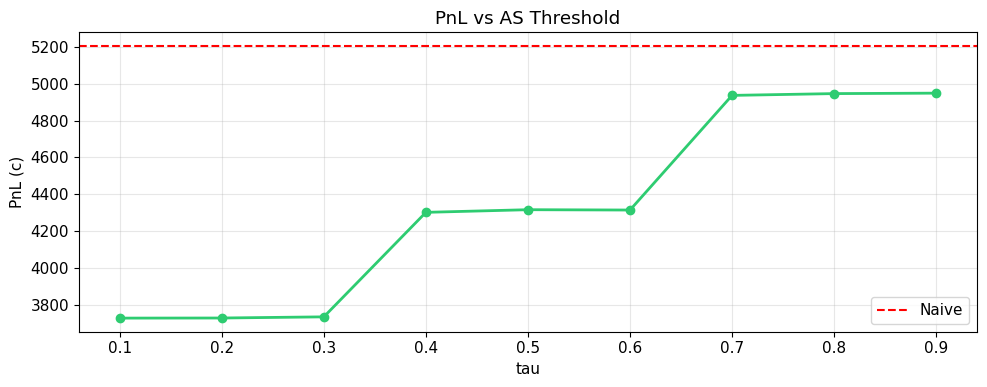

In [14]:
sweep_tkr = max(all_as.keys(), key=lambda k: len(all_as[k].prices))
sweep_df = sweep_thresholds(all_as[sweep_tkr], mtm_horizon_trades=60)
print(f"Threshold sweep: {sweep_tkr}")
print(sweep_df.to_string(index=False, float_format="%.2f"))

fig, ax = plt.subplots(figsize=(10, 4))
inf = sweep_df[sweep_df.strategy == "as_informed"]
ax.plot(inf.threshold, inf.net_pnl_c, "o-", color="#2ecc71", lw=2)
ax.axhline(sweep_df.iloc[0].net_pnl_c, color="red", ls="--", label="Naive")
ax.set_xlabel("tau"); ax.set_ylabel("PnL (c)"); ax.set_title("PnL vs AS Threshold"); ax.legend()
plt.tight_layout()
plt.savefig("../figures/election_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cross-State Co-Jump Analysis

Election night: when one state's results move, correlated markets (same party, swing states) may jump together.

In [15]:
g5 = {}
for tkr, ar in all_as.items():
    g5[tkr] = pd.Series(ar.gamma, index=pd.to_datetime(ar.timestamps)).resample("5min").max().dropna()
ga = pd.DataFrame(g5).dropna(thresh=2)
print(f"Co-jump analysis: {len(ga)} 5-min windows across {len(ga.columns)} states")
print("\nCross-correlation of gamma (5-min max):")
print(ga.corr().round(3).to_string())

Co-jump analysis: 6693 5-min windows across 17 states

Cross-correlation of gamma (5-min max):
                  PRESPARTYPA-24-R  PRESPARTYPA-24-D  PRESPARTYNV-24-R  PRESPARTYNV-24-D  PRESPARTYVA-24-R  PRESPARTYAZ-24-D  PRESPARTYAZ-24-R  PRESPARTYVA-24-D  SENATEWI-24-R  SENATEWI-24-D  PRESPARTYIL-24-R  PRESPARTYCO-24-R  PRESPARTYCO-24-D  PRESPARTYIL-24-D  PRESPARTYIN-24-D  PRESPARTYMO-24-D  PRESPARTYIN-24-R
PRESPARTYPA-24-R             1.000             0.242             0.222             0.224             0.189             0.238             0.156             0.135          0.160          0.145            -0.007             0.160             0.105            -0.043             0.137            -0.117            -0.170
PRESPARTYPA-24-D             0.242             1.000             0.232             0.260             0.228             0.257             0.220             0.134          0.143          0.167            -0.012             0.166             0.027            -0.072         

## 8. Summary

In [16]:
print("=" * 70)
print("ADVERSE SELECTION — 2024 ELECTION MARKETS SUMMARY")
print("=" * 70)
tt = sum(len(ar.prices) for ar in all_as.values())
te = sum((ar.as_score > 0.9).sum() for ar in all_as.values())
print(f"Tickers: {len(all_as)} | Trades: {tt:,} | AS events: {te:,} ({te/tt*100:.1f}%)")
nt = sum(c.naive.net_pnl for c in comparisons.values())
it = sum(c.informed.net_pnl for c in comparisons.values())
print(f"Backtest (tau=0.9): Naive={nt:.1f}c Informed={it:.1f}c Delta={it-nt:+.1f}c")
improved = sum(1 for c in comparisons.values() if c.pnl_improvement > 0)
print(f"Improved: {improved}/{len(comparisons)} tickers")
print("=" * 70)

ADVERSE SELECTION — 2024 ELECTION MARKETS SUMMARY
Tickers: 17 | Trades: 113,499 | AS events: 6,614 (5.8%)
Backtest (tau=0.9): Naive=24419.4c Informed=22991.8c Delta=-1427.6c
Improved: 2/17 tickers
